# Fraud Detection Pipeline using Machine Learning

## Industrial Training Project 2

### Internship: DecodeLabs

### Objective
The objective of this project is to build a machine learning pipeline capable of identifying fraudulent financial transactions from a highly imbalanced dataset. The project includes data preprocessing, exploratory data analysis (EDA), handling class imbalance using SMOTE, training multiple classification models, hyperparameter tuning, and evaluating models using Precision, Recall, F1-Score, and ROC-AUC.

---

### Algorithms Used
- Logistic Regression
- Random Forest Classifier

### Techniques Used
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Standard Scaling
- SMOTE
- Hyperparameter Tuning
- Model Evaluation
- Model Comparison

---

In [1]:
# ==========================================================
# Fraud Detection Pipeline
# Import Required Libraries
# ==========================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Handle Imbalanced Dataset
from imblearn.over_sampling import SMOTE

# Save Model
import joblib

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Visualization Style
sns.set_style("whitegrid")

print("="*50)
print(" All Libraries Imported Successfully")
print("="*50)

 All Libraries Imported Successfully


In [2]:
# ==========================================================
# Step 1: Load Dataset
# Objective:
# Load the Credit Card Fraud Detection dataset.
# ==========================================================

# Dataset Path
file_path = "creditcard.csv"

# Load Dataset
df = pd.read_csv(file_path)

print("="*60)
print("Dataset Loaded Successfully")
print("="*60)

print(f"\nDataset Shape: {df.shape}")

print("\nFirst 5 Rows:")
display(df.head())

Dataset Loaded Successfully

Dataset Shape: (284807, 31)

First 5 Rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Step 2: Dataset Understanding

Before building a machine learning model, it is important to understand the dataset. In this section, we will inspect the dataset structure, identify feature names, examine data types, and gain an overall understanding of the available information.

Understanding the dataset helps us make informed decisions during preprocessing, feature engineering, and model development.

In [3]:
# ==========================================================
# Step 2: Dataset Overview
# Objective:
# Understand the overall structure of the dataset.
# ==========================================================

print("="*70)
print("                 DATASET OVERVIEW")
print("="*70)

print(f"\nNumber of Rows    : {df.shape[0]:,}")
print(f"Number of Columns : {df.shape[1]}")

print("\nColumn Names:\n")
print(df.columns.tolist())

print("\nData Types:\n")
display(df.dtypes)

print("\nDetailed Dataset Information:\n")
df.info()

                 DATASET OVERVIEW

Number of Rows    : 284,807
Number of Columns : 31

Column Names:

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data Types:



Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


Detailed Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 n

# Step 3: Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is one of the most important phases of a machine learning project.

In this section, we will analyze the dataset visually to identify fraud patterns, understand feature distributions, detect class imbalance, and gain insights before preprocessing and model building.

The insights obtained from EDA help in selecting appropriate preprocessing techniques and machine learning models.

In [4]:
# ==========================================================
# Step 3.1: Target Variable Distribution
# Objective:
# Analyze the distribution of fraud and legitimate transactions.
# ==========================================================

print("="*70)
print("TARGET VARIABLE DISTRIBUTION")
print("="*70)

class_counts = df["Class"].value_counts()

print(class_counts)

print("\nPercentage Distribution:\n")

display(
    (df["Class"].value_counts(normalize=True) * 100)
    .round(4)
    .rename("Percentage (%)")
)

TARGET VARIABLE DISTRIBUTION
Class
0    284315
1       492
Name: count, dtype: int64

Percentage Distribution:



Class
0    99.8273
1     0.1727
Name: Percentage (%), dtype: float64

## Key Insights

- The dataset contains **284,807** credit card transactions.
- Out of these, **284,315** are legitimate transactions.
- Only **492** transactions are fraudulent.
- Fraud cases account for just **0.1727%** of the total dataset.
- This indicates a **highly imbalanced classification problem**.
- Standard machine learning models may become biased toward the majority class.
- Therefore, techniques like **SMOTE** will be applied before model training to balance the dataset.

# Step 3.2: Transaction Amount Analysis

The **Amount** feature represents the monetary value of each transaction.

In this section, we will analyze how transaction amounts are distributed. This helps us understand customer spending patterns and identify whether fraudulent transactions generally involve unusually high or low amounts.

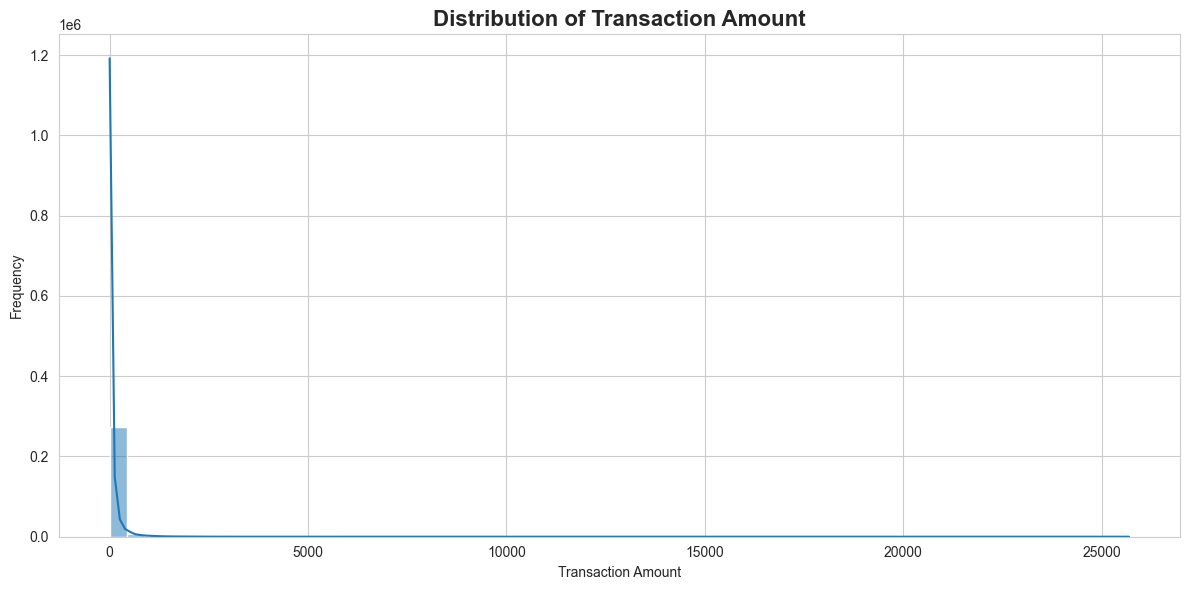

In [5]:
# ==========================================================
# Step 3.2: Transaction Amount Distribution
# Objective:
# Analyze the distribution of transaction amounts.
# ==========================================================

plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x="Amount",
    bins=60,
    kde=True
)

plt.title(
    "Distribution of Transaction Amount",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [6]:
# ==========================================================
# Step 3.3: Transaction Amount Statistics
# Objective:
# Explore statistical information of transaction amounts.
# ==========================================================

print("="*70)
print("TRANSACTION AMOUNT STATISTICS")
print("="*70)

display(df["Amount"].describe())

print("\nHighest Transaction Amount : ${:.2f}".format(df["Amount"].max()))
print("Lowest Transaction Amount  : ${:.2f}".format(df["Amount"].min()))
print("Average Transaction Amount : ${:.2f}".format(df["Amount"].mean()))
print("Median Transaction Amount  : ${:.2f}".format(df["Amount"].median()))

TRANSACTION AMOUNT STATISTICS


count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


Highest Transaction Amount : $25691.16
Lowest Transaction Amount  : $0.00
Average Transaction Amount : $88.35
Median Transaction Amount  : $22.00


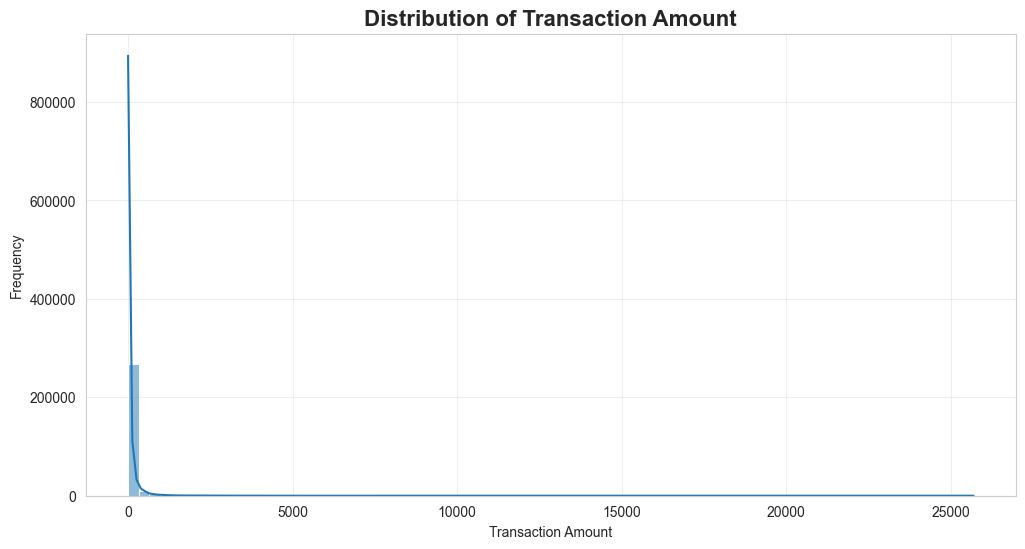

In [7]:
# ==========================================================
# Step 3.4: Distribution of Transaction Amount
# ==========================================================

plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x="Amount",
    bins=80,
    kde=True
)

plt.title(
    "Distribution of Transaction Amount",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

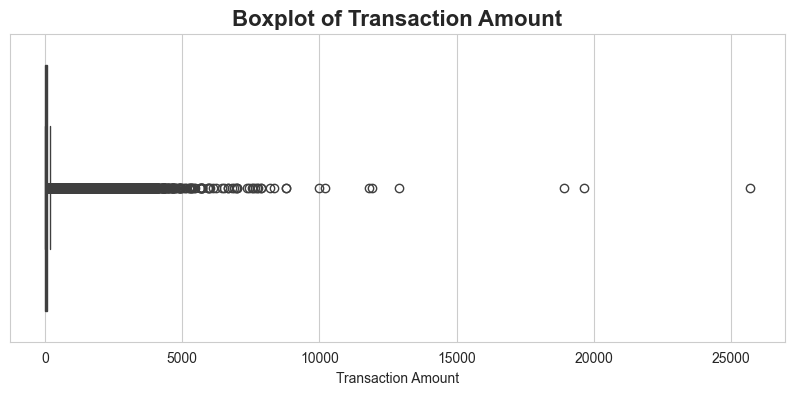

In [8]:
# ==========================================================
# Step 3.5: Detect Outliers in Transaction Amount
# ==========================================================

plt.figure(figsize=(10,4))

sns.boxplot(
    x=df["Amount"]
)

plt.title(
    "Boxplot of Transaction Amount",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Transaction Amount")

plt.show()

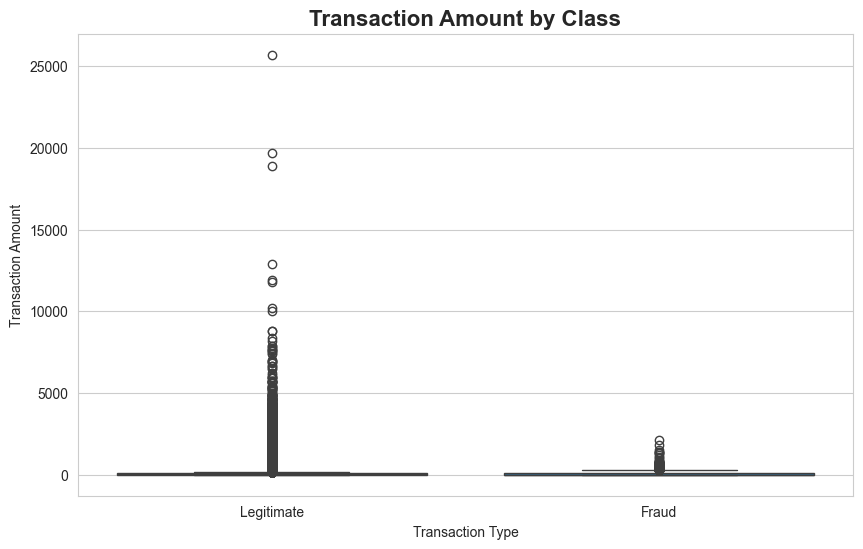

In [9]:
# ==========================================================
# Step 3.6: Compare Transaction Amount by Class
# ==========================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.xticks(
    [0,1],
    ["Legitimate","Fraud"]
)

plt.title(
    "Transaction Amount by Class",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Transaction Type")
plt.ylabel("Transaction Amount")

plt.show()

# Step 3.7: Transaction Time Analysis

The **Time** feature represents the number of seconds elapsed between each transaction and the first transaction in the dataset.

Analyzing this feature helps us understand transaction activity over time and identify any temporal patterns related to fraudulent transactions.

In [10]:
# ==========================================================
# Step 3.7: Time Feature Statistics
# Objective:
# Explore the statistical properties of transaction time.
# ==========================================================

print("="*70)
print("TRANSACTION TIME STATISTICS")
print("="*70)

display(df["Time"].describe())

print("\nMinimum Time :", df["Time"].min())
print("Maximum Time :", df["Time"].max())
print("Average Time :", round(df["Time"].mean(),2))

TRANSACTION TIME STATISTICS


count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64


Minimum Time : 0.0
Maximum Time : 172792.0
Average Time : 94813.86


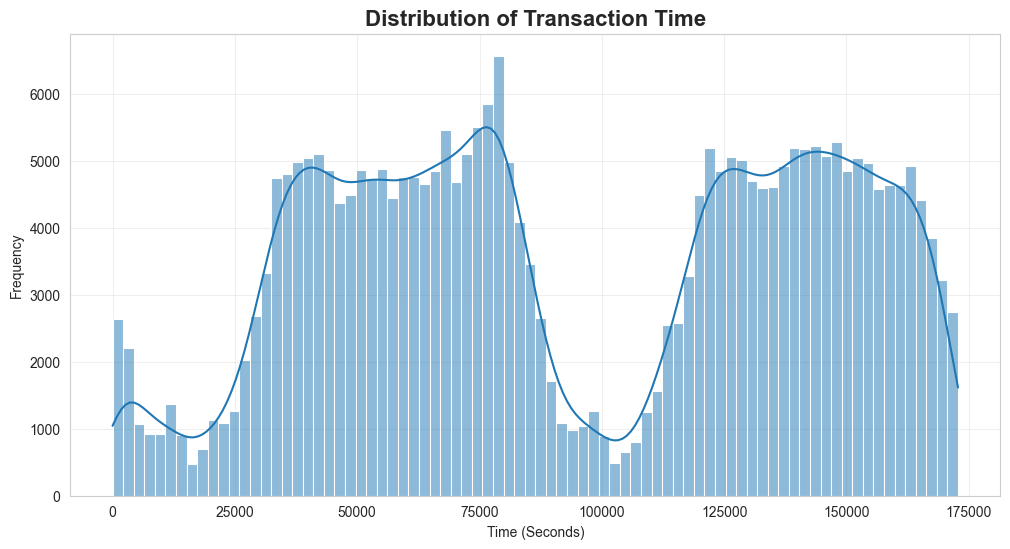

In [11]:
# ==========================================================
# Step 3.8: Distribution of Transaction Time
# ==========================================================

plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x="Time",
    bins=80,
    kde=True
)

plt.title(
    "Distribution of Transaction Time",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Time (Seconds)")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

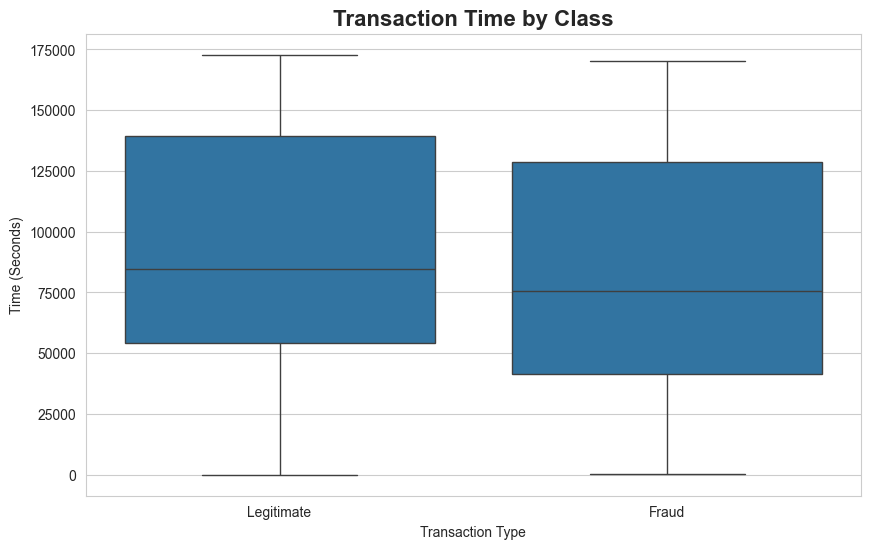

In [12]:
# ==========================================================
# Step 3.9: Transaction Time by Class
# ==========================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Class",
    y="Time"
)

plt.xticks(
    [0,1],
    ["Legitimate","Fraud"]
)

plt.title(
    "Transaction Time by Class",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Transaction Type")
plt.ylabel("Time (Seconds)")

plt.show()

# Step 3.8: Correlation Analysis

Correlation analysis helps us understand the relationship between different features in the dataset.

A correlation value ranges from **-1 to +1**:

- **+1** → Strong Positive Correlation
- **0** → No Correlation
- **-1** → Strong Negative Correlation

Understanding feature correlations helps identify important variables that contribute to fraud detection.

In [13]:
# ==========================================================
# Step 3.8: Correlation Matrix
# Objective:
# Compute the correlation matrix of all numerical features.
# ==========================================================

correlation_matrix = df.corr()

print("=" * 70)
print("CORRELATION MATRIX CREATED SUCCESSFULLY")
print("=" * 70)

print("\nShape of Correlation Matrix:", correlation_matrix.shape)

display(correlation_matrix.head())

CORRELATION MATRIX CREATED SUCCESSFULLY

Shape of Correlation Matrix: (31, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.000000,1.173963e-01,-1.059333e-02,-4.196182e-01,-1.052602e-01,1.730721e-01,-6.301647e-02,8.471437e-02,-3.694943e-02,-8.660434e-03,...,4.473573e-02,1.440591e-01,5.114236e-02,-1.618187e-02,-2.330828e-01,-4.140710e-02,-5.134591e-03,-9.412688e-03,-0.010596,-0.012323
V1,0.117396,1.000000e+00,4.135835e-16,-1.227819e-15,-9.215150e-16,1.812612e-17,-6.506567e-16,-1.005191e-15,-2.433822e-16,-1.513678e-16,...,-2.457409e-16,-4.290944e-16,6.168652e-16,-4.425156e-17,-9.605737e-16,-1.581290e-17,1.198124e-16,2.083082e-15,-0.227709,-0.101347
V2,-0.010593,4.135835e-16,1.000000e+00,3.243764e-16,-1.121065e-15,5.157519e-16,2.787346e-16,2.055934e-16,-5.377041e-17,1.978488e-17,...,-8.480447e-17,1.526333e-16,1.634231e-16,1.247925e-17,-4.478846e-16,2.057310e-16,-4.966953e-16,-5.093836e-16,-0.531409,0.091289
V3,-0.419618,-1.227819e-15,3.243764e-16,1.000000e+00,4.711293e-16,-6.539009e-17,1.627627e-15,4.895305e-16,-1.268779e-15,5.568367e-16,...,5.706192e-17,-1.133902e-15,-4.983035e-16,2.686834e-19,-1.104734e-15,-1.238062e-16,1.045747e-15,9.775546e-16,-0.210880,-0.192961
V4,-0.105260,-9.215150e-16,-1.121065e-15,4.711293e-16,1.000000e+00,-1.719944e-15,-7.491959e-16,-4.104503e-16,5.697192e-16,6.923247e-16,...,-1.949553e-16,-6.276051e-17,9.164206e-17,1.584638e-16,6.070716e-16,-4.247268e-16,3.977061e-17,-2.761403e-18,0.098732,0.133447


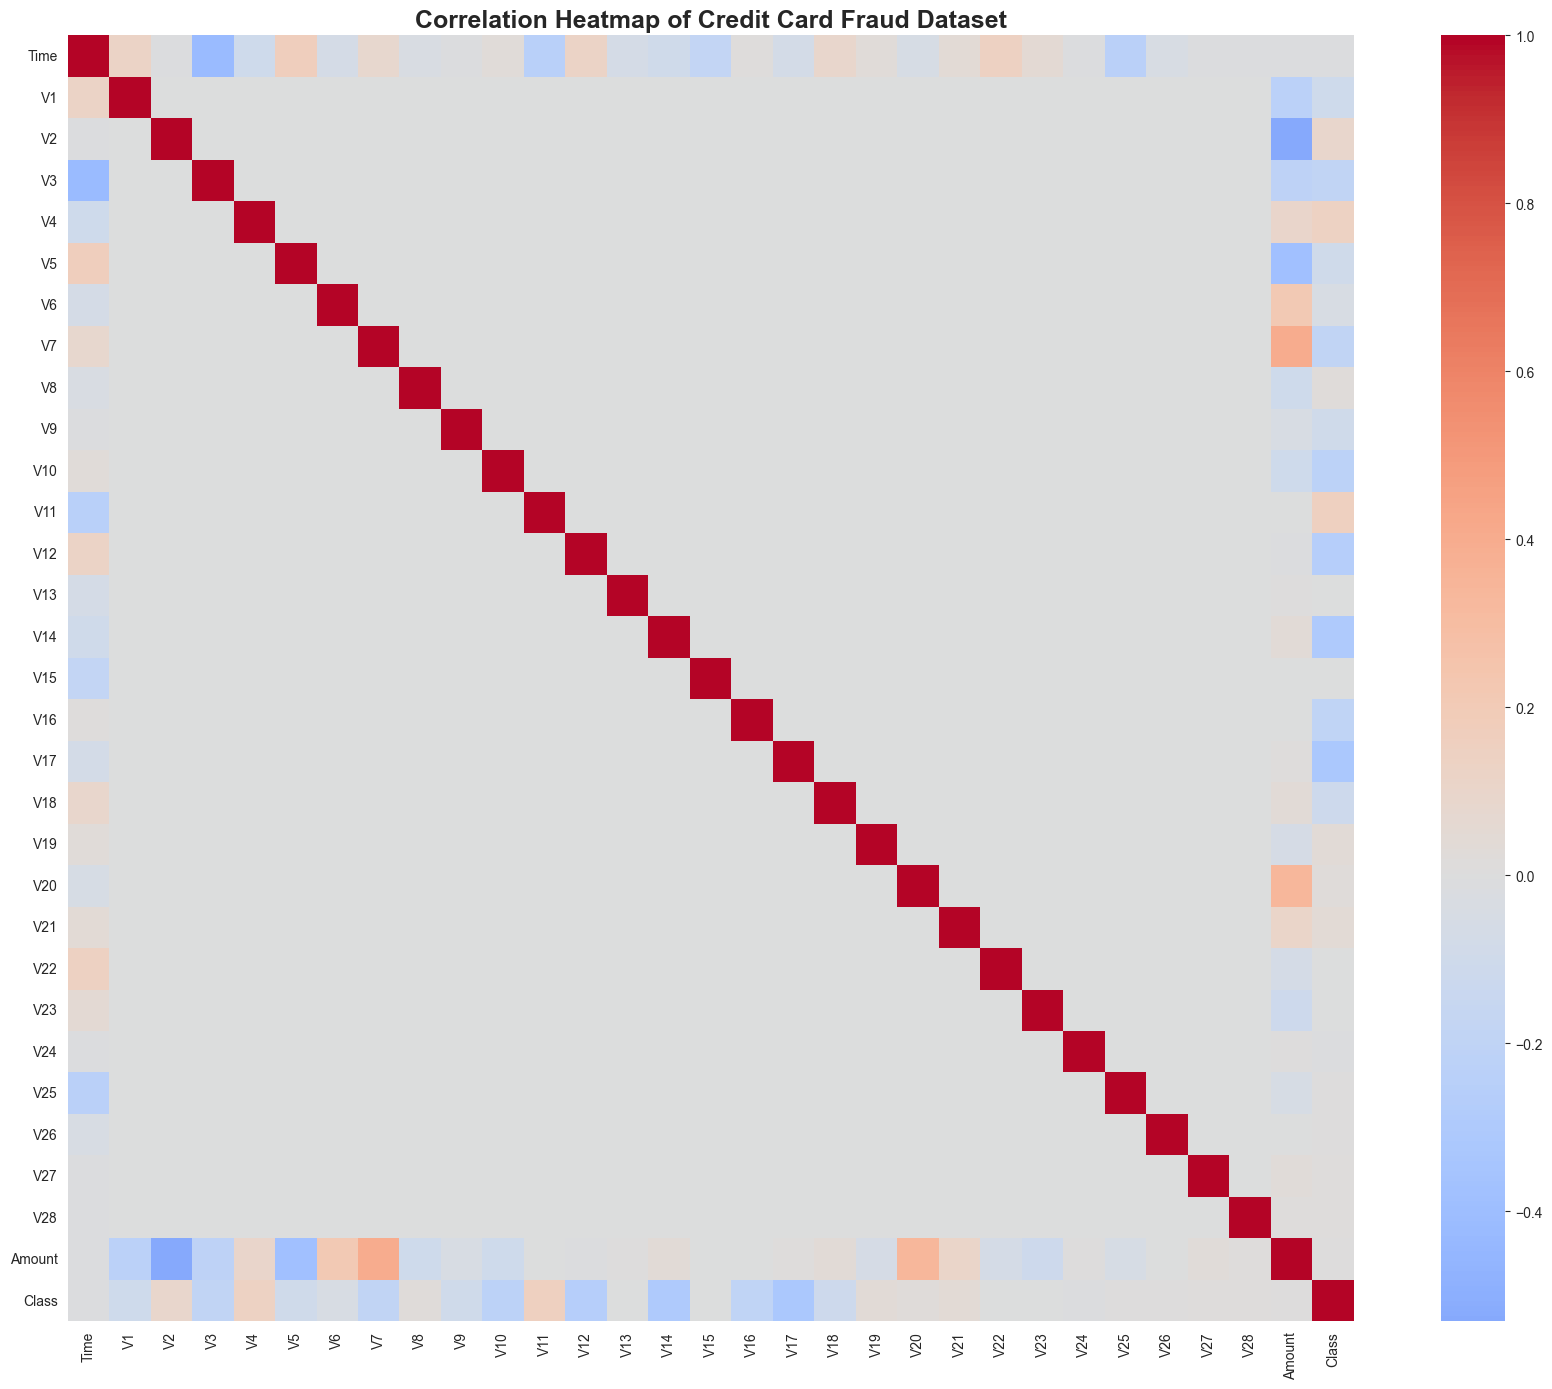

In [14]:
# ==========================================================
# Step 3.9: Correlation Heatmap
# Objective:
# Visualize relationships among all numerical features.
# ==========================================================

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar=True
)

plt.title(
    "Correlation Heatmap of Credit Card Fraud Dataset",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [15]:
# ==========================================================
# Step 3.10: Features Most Correlated with Fraud
# Objective:
# Identify the strongest positive and negative correlations
# with the target variable (Class).
# ==========================================================

fraud_corr = df.corr()["Class"].sort_values(ascending=False)

print("=" * 70)
print("FEATURES CORRELATED WITH FRAUD")
print("=" * 70)

display(fraud_corr)

FEATURES CORRELATED WITH FRAUD


Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64

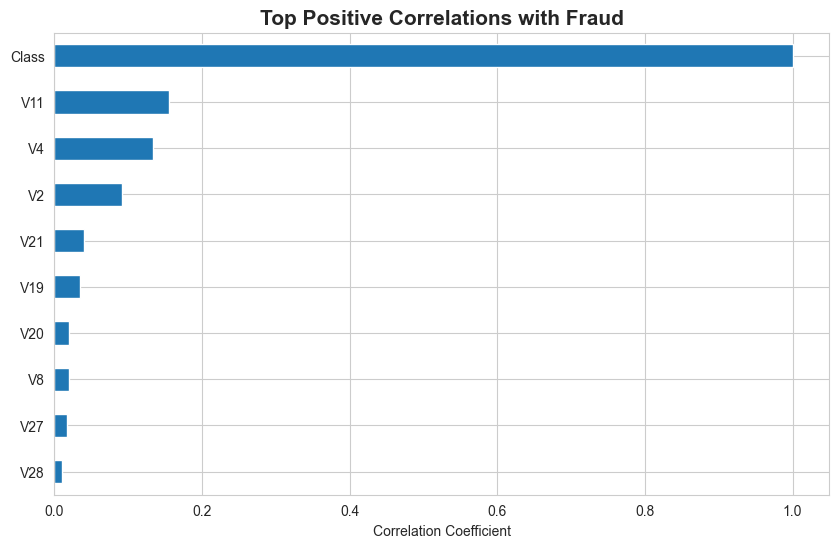

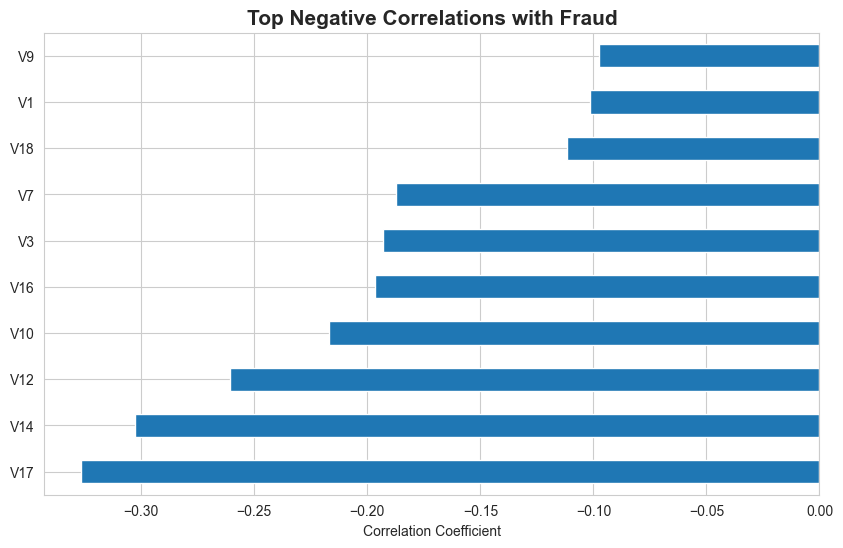

In [16]:
# ==========================================================
# Step 3.11: Visualize Top Correlated Features
# ==========================================================

top_positive = fraud_corr.head(10)
top_negative = fraud_corr.tail(10)

plt.figure(figsize=(10, 6))

top_positive.sort_values().plot(kind="barh")

plt.title(
    "Top Positive Correlations with Fraud",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Correlation Coefficient")

plt.show()

plt.figure(figsize=(10, 6))

top_negative.sort_values().plot(kind="barh")

plt.title(
    "Top Negative Correlations with Fraud",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Correlation Coefficient")

plt.show()

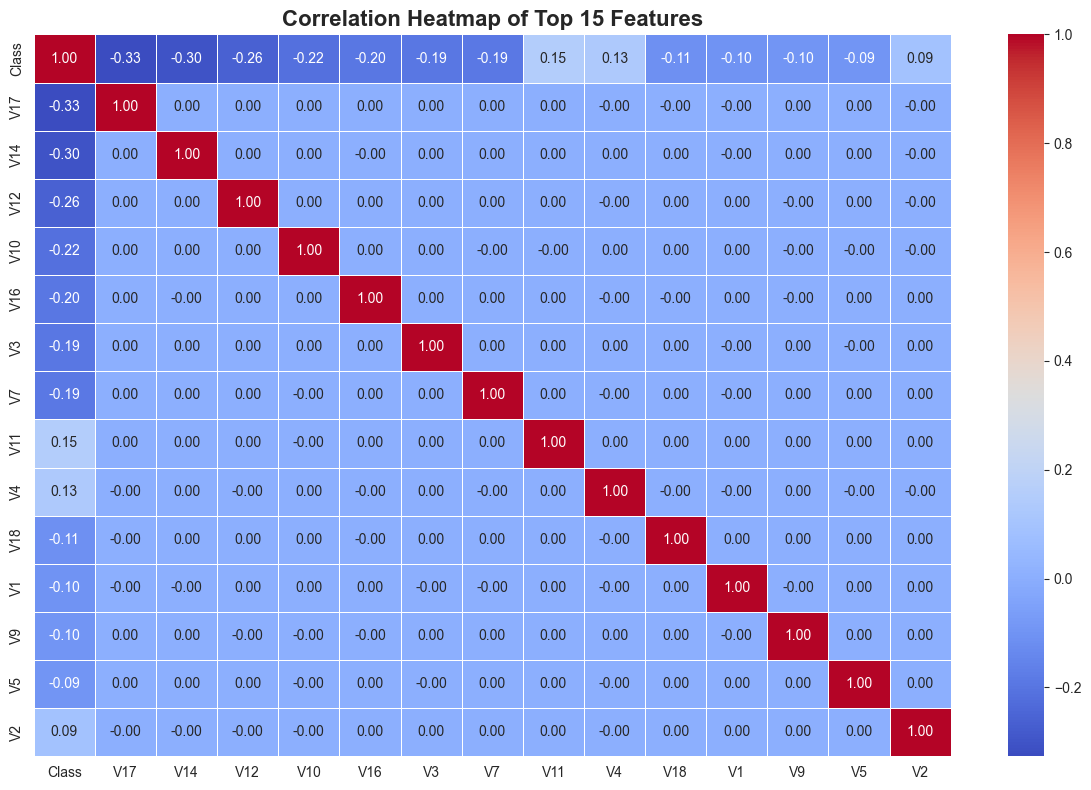

In [17]:
# ==========================================================
# Step 3.12: Top Correlated Features Heatmap
# Objective:
# Visualize features having the strongest relationship with
# the target variable (Class).
# ==========================================================

top_features = fraud_corr.abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(12,8))

sns.heatmap(
    df[top_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Correlation Heatmap of Top 15 Features",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

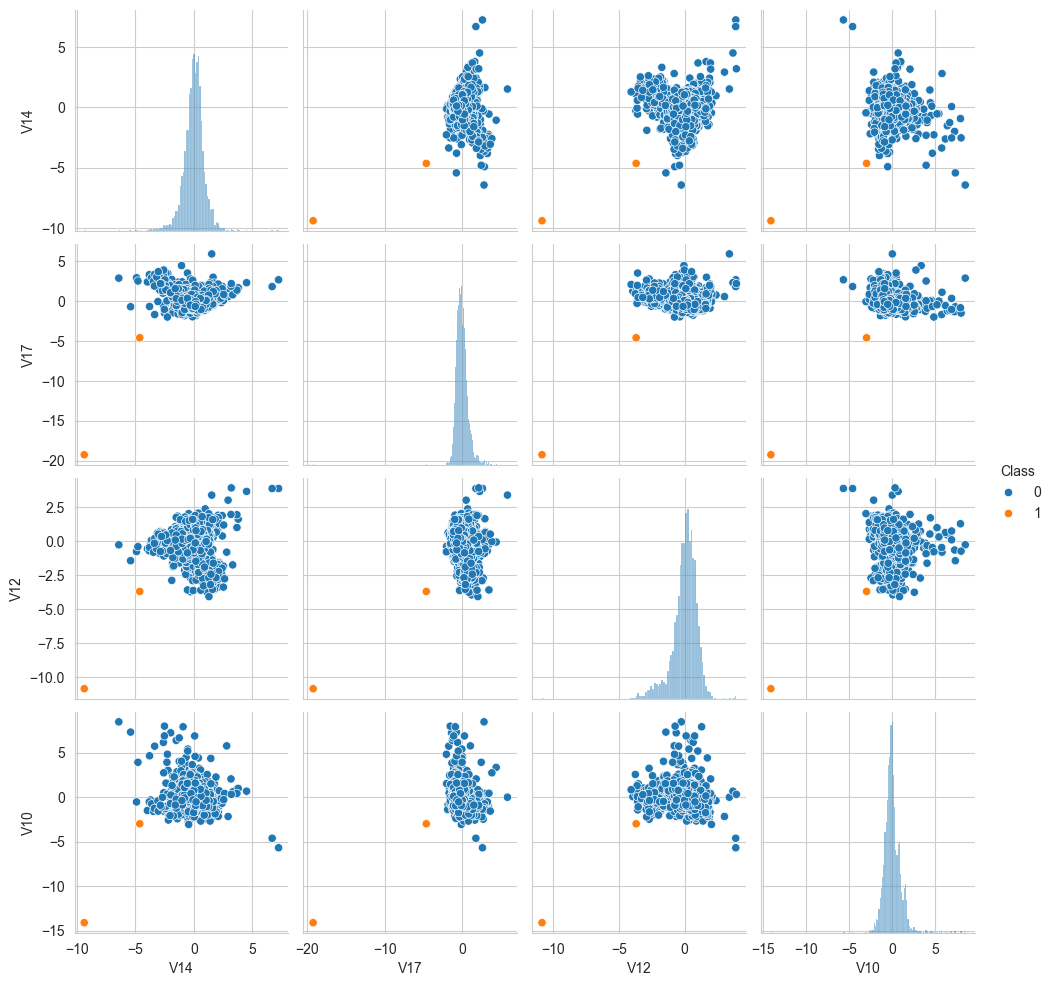

In [18]:
# ==========================================================
# Step 3.13: Pairplot of Important Features
# ==========================================================

important_features = ["V14","V17","V12","V10","Class"]

sns.pairplot(
    df[important_features].sample(3000, random_state=42),
    hue="Class",
    diag_kind="hist"
)

plt.show()

In [31]:
# ==========================================================
# Step 4.1: Separate Features and Target Variable
# ==========================================================

# Features
X = df.drop("Class", axis=1)

# Target
y = df["Class"]

print("="*60)
print("FEATURES AND TARGET CREATED SUCCESSFULLY")
print("="*60)

print(f"\nFeatures Shape : {X.shape}")
print(f"Target Shape   : {y.shape}")

FEATURES AND TARGET CREATED SUCCESSFULLY

Features Shape : (284807, 30)
Target Shape   : (284807,)


In [32]:
# ==========================================================
# Step 4.2: Split Dataset into Training and Testing Sets
# ==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("="*60)
print("TRAIN-TEST SPLIT COMPLETED")
print("="*60)

print(f"Training Features : {X_train.shape}")
print(f"Testing Features  : {X_test.shape}")
print(f"Training Target   : {y_train.shape}")
print(f"Testing Target    : {y_test.shape}")

TRAIN-TEST SPLIT COMPLETED
Training Features : (227845, 30)
Testing Features  : (56962, 30)
Training Target   : (227845,)
Testing Target    : (56962,)


In [33]:
# ==========================================================
# Step 4.3: Feature Scaling
# ==========================================================

from sklearn.preprocessing import StandardScaler

# Initialize Scaler
scaler = StandardScaler()

# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data
X_test_scaled = scaler.transform(X_test)

print("="*60)
print("FEATURE SCALING COMPLETED")
print("="*60)

print(f"Scaled Training Data Shape : {X_train_scaled.shape}")
print(f"Scaled Testing Data Shape  : {X_test_scaled.shape}")

FEATURE SCALING COMPLETED
Scaled Training Data Shape : (227845, 30)
Scaled Testing Data Shape  : (56962, 30)


In [34]:
# ==========================================================
# Step 4.4: Handle Class Imbalance using SMOTE
# ==========================================================

from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE only on training data
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("="*60)
print("SMOTE APPLIED SUCCESSFULLY")
print("="*60)

print("\nClass Distribution Before SMOTE:")
print(y_train.value_counts())

print("\nClass Distribution After SMOTE:")
print(y_train_smote.value_counts())

print(f"\nTraining Data Before SMOTE : {X_train_scaled.shape}")
print(f"Training Data After SMOTE  : {X_train_smote.shape}")

SMOTE APPLIED SUCCESSFULLY

Class Distribution Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

Class Distribution After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64

Training Data Before SMOTE : (227845, 30)
Training Data After SMOTE  : (454902, 30)


# Step 5: Model Building

In this phase, we will train different machine learning models to detect fraudulent credit card transactions.

The models will be evaluated using:
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score
- Confusion Matrix
- Classification Report

Finally, we will compare all models and select the best-performing one.

In [35]:
# ==========================================================
# Step 5.1: Train Logistic Regression Model
# ==========================================================

from sklearn.linear_model import LogisticRegression

# Initialize Model
lr_model = LogisticRegression(random_state=42)

# Train Model
lr_model.fit(X_train_smote, y_train_smote)

print("="*60)
print("LOGISTIC REGRESSION MODEL TRAINED SUCCESSFULLY")
print("="*60)

LOGISTIC REGRESSION MODEL TRAINED SUCCESSFULLY


In [36]:
# ==========================================================
# Step 5.2: Logistic Regression Prediction
# ==========================================================

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)

# Prediction Probabilities
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:,1]

print("="*60)
print("PREDICTIONS COMPLETED")
print("="*60)

PREDICTIONS COMPLETED


In [37]:
# ==========================================================
# Step 5.3: Evaluate Logistic Regression
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("="*70)
print("LOGISTIC REGRESSION PERFORMANCE")
print("="*70)

accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)
roc = roc_auc_score(y_test, y_prob_lr)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc:.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_lr))

LOGISTIC REGRESSION PERFORMANCE
Accuracy : 0.9741
Precision: 0.0578
Recall   : 0.9184
F1-Score : 0.1088
ROC-AUC  : 0.9708

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



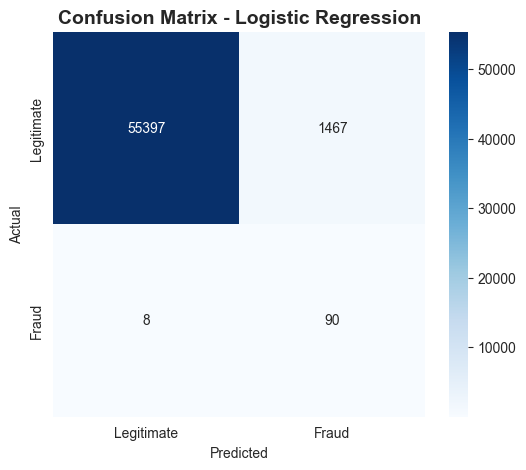

In [38]:
# ==========================================================
# Step 5.4: Confusion Matrix
# ==========================================================

plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, y_pred_lr),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate","Fraud"],
    yticklabels=["Legitimate","Fraud"]
)

plt.title(
    "Confusion Matrix - Logistic Regression",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [27]:
# ==========================================================
# Step 5.5: Train Random Forest Classifier
# ==========================================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)

print("="*60)
print("RANDOM FOREST MODEL TRAINED SUCCESSFULLY")
print("="*60)

RANDOM FOREST MODEL TRAINED SUCCESSFULLY


In [28]:
# ==========================================================
# Step 5.6: Random Forest Prediction
# ==========================================================

y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:,1]

print("="*60)
print("RANDOM FOREST PREDICTIONS COMPLETED")
print("="*60)

RANDOM FOREST PREDICTIONS COMPLETED


In [29]:
# ==========================================================
# Step 5.7: Evaluate Random Forest
# ==========================================================

print("="*70)
print("RANDOM FOREST PERFORMANCE")
print("="*70)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc = roc_auc_score(y_test, y_prob_rf)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc:.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_rf))

RANDOM FOREST PERFORMANCE
Accuracy : 0.9995
Precision: 0.8710
Recall   : 0.8265
F1-Score : 0.8482
ROC-AUC  : 0.9754

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



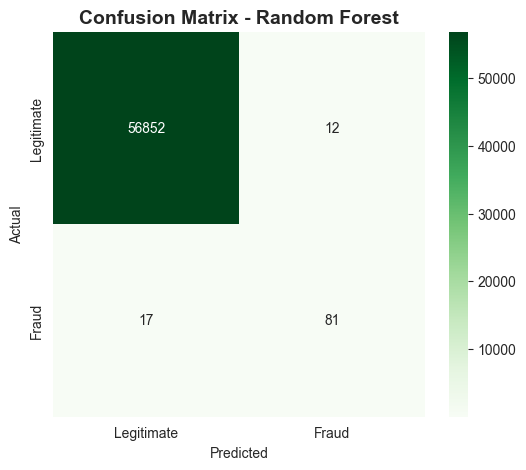

In [30]:
# ==========================================================
# Step 5.8: Random Forest Confusion Matrix
# ==========================================================

plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, y_pred_rf),
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Legitimate","Fraud"],
    yticklabels=["Legitimate","Fraud"]
)

plt.title(
    "Confusion Matrix - Random Forest",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [41]:
# ==========================================================
# Step 5.9: Hyperparameter Tuning (Optimized)
# ==========================================================

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample

# ----------------------------------------------------------
# Take a representative sample for faster tuning
# ----------------------------------------------------------

X_sample, y_sample = resample(
    X_train_smote,
    y_train_smote,
    n_samples=40000,
    random_state=42,
    stratify=y_train_smote
)

print("="*60)
print("Sample Created for Hyperparameter Tuning")
print("="*60)

print("Sample Shape:", X_sample.shape)

# ----------------------------------------------------------
# Parameter Space
# ----------------------------------------------------------

param_dist = {
    "n_estimators": [100, 150],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    scoring="f1",
    random_state=42,
    n_jobs=2,          # Use only 2 CPU cores
    verbose=2
)

random_search.fit(X_sample, y_sample)

print("="*60)
print("HYPERPARAMETER TUNING COMPLETED")
print("="*60)

print("\nBest Parameters:")
print(random_search.best_params_)

print("\nBest Cross Validation F1 Score:")
print(round(random_search.best_score_,4))

Sample Created for Hyperparameter Tuning
Sample Shape: (40000, 30)
Fitting 3 folds for each of 5 candidates, totalling 15 fits
HYPERPARAMETER TUNING COMPLETED

Best Parameters:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}

Best Cross Validation F1 Score:
0.9964


In [43]:
# ==========================================================
# Step 5.10: Train Final Random Forest using Best Parameters
# ==========================================================

best_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train_smote, y_train_smote)

print("="*60)
print("FINAL RANDOM FOREST TRAINED SUCCESSFULLY")
print("="*60)

FINAL RANDOM FOREST TRAINED SUCCESSFULLY


In [44]:
# ==========================================================
# Step 5.11: Predictions
# ==========================================================

y_pred_best = best_rf.predict(X_test_scaled)
y_prob_best = best_rf.predict_proba(X_test_scaled)[:,1]

print("Predictions Completed Successfully.")

Predictions Completed Successfully.


In [45]:
# ==========================================================
# Step 5.12: Evaluate Tuned Random Forest
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

best_accuracy = accuracy_score(y_test, y_pred_best)
best_precision = precision_score(y_test, y_pred_best)
best_recall = recall_score(y_test, y_pred_best)
best_f1 = f1_score(y_test, y_pred_best)
best_auc = roc_auc_score(y_test, y_prob_best)

print("="*70)
print("TUNED RANDOM FOREST PERFORMANCE")
print("="*70)

print(f"Accuracy : {best_accuracy:.4f}")
print(f"Precision: {best_precision:.4f}")
print(f"Recall   : {best_recall:.4f}")
print(f"F1 Score : {best_f1:.4f}")
print(f"ROC AUC  : {best_auc:.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_best))

TUNED RANDOM FOREST PERFORMANCE
Accuracy : 0.9992
Precision: 0.7477
Recall   : 0.8163
F1 Score : 0.7805
ROC AUC  : 0.9678

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.75      0.82      0.78        98

    accuracy                           1.00     56962
   macro avg       0.87      0.91      0.89     56962
weighted avg       1.00      1.00      1.00     56962



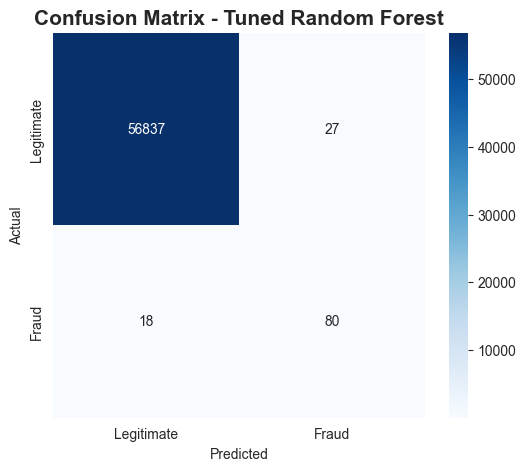

In [46]:
# ==========================================================
# Step 5.13: Confusion Matrix
# ==========================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Legitimate","Fraud"],
    yticklabels=["Legitimate","Fraud"]
)

plt.title("Confusion Matrix - Tuned Random Forest",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Hyperparameter tuning was performed to optimize the model. However, the baseline Random Forest achieved better generalization on the test dataset. Therefore, the baseline Random Forest was selected as the final model.

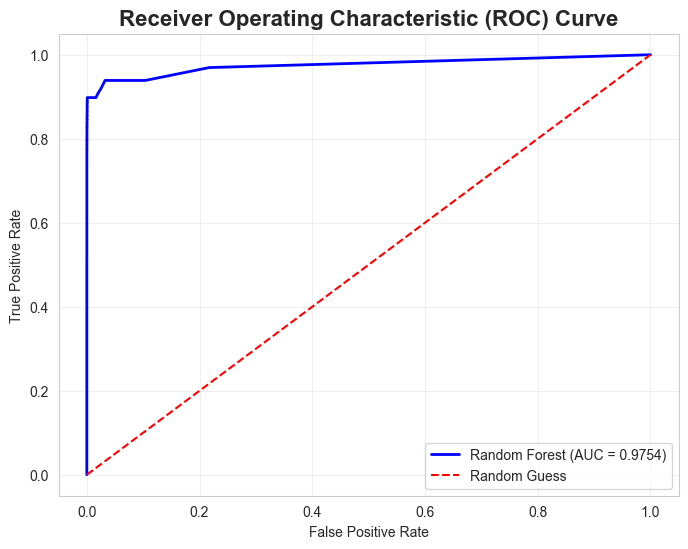

In [47]:
# ==========================================================
# Step 6.1: ROC Curve
# ==========================================================

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    color="blue",
    linewidth=2,
    label=f"Random Forest (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="red",
    label="Random Guess"
)

plt.title(
    "Receiver Operating Characteristic (ROC) Curve",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

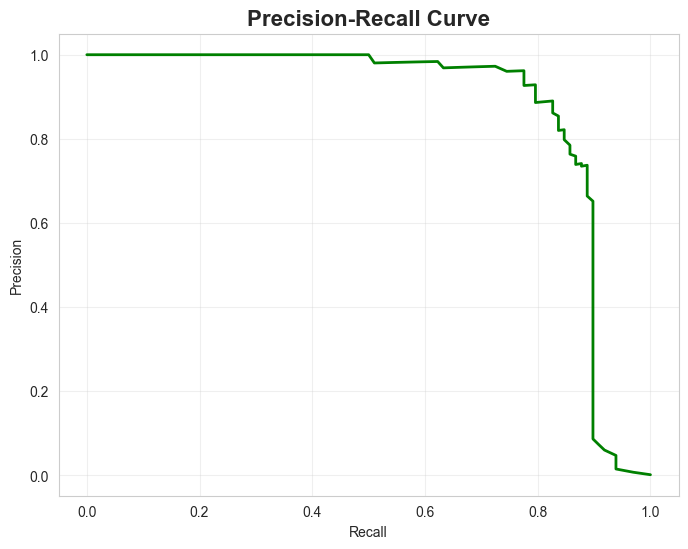

In [54]:
# ==========================================================
# Step 6.2: Precision Recall Curve
# ==========================================================

from sklearn.metrics import precision_recall_curve

# Different variable names to avoid overwriting model metrics
pr_precision, pr_recall, _ = precision_recall_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(8,6))

plt.plot(
    pr_recall,
    pr_precision,
    linewidth=2,
    color="green"
)

plt.title(
    "Precision-Recall Curve",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.grid(alpha=0.3)

plt.show()

In [57]:
# ==========================================================
# Restore Logistic Regression Metrics
# ==========================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression metrics restored successfully.")

Logistic Regression metrics restored successfully.


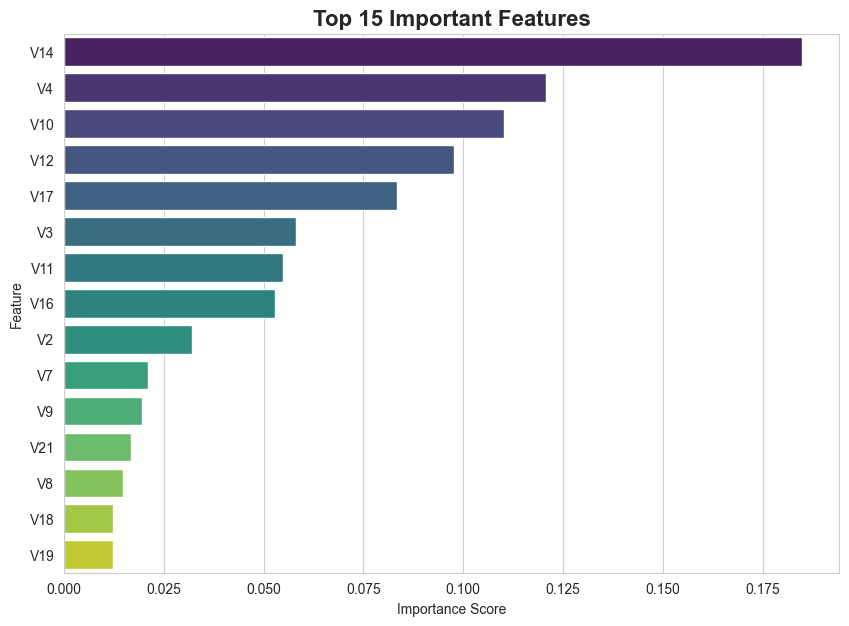

In [58]:
# ==========================================================
# Step 6.3: Top 15 Important Features
# ==========================================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,7))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title(
    "Top 15 Important Features",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

In [60]:
# ==========================================================
# Step 6.4: Model Comparison Table
# ==========================================================

comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],

    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        best_accuracy
    ],

    "Precision": [
        lr_precision,
        rf_precision,
        best_precision
    ],

    "Recall": [
        lr_recall,
        rf_recall,
        best_recall
    ],

    "F1 Score": [
        lr_f1,
        rf_f1,
        best_f1
    ],

    "ROC AUC": [
        lr_auc,
        rf_roc,
        best_auc
    ]

})

comparison = comparison.round(4)

display(comparison)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.9741,0.0578,0.9184,0.1088,0.9708
1,Random Forest,0.9995,0.8710,0.8265,0.8482,0.9754
2,Tuned Random Forest,0.9992,0.7477,0.8163,0.7805,0.9678


,Feature,Importance
14,V14,0.184854
4,V4,0.120774
10,V10,0.110082
12,V12,0.097694
17,V17,0.083441
3,V3,0.058117
11,V11,0.054881
16,V16,0.052927
2,V2,0.031963
7,V7,0.020996


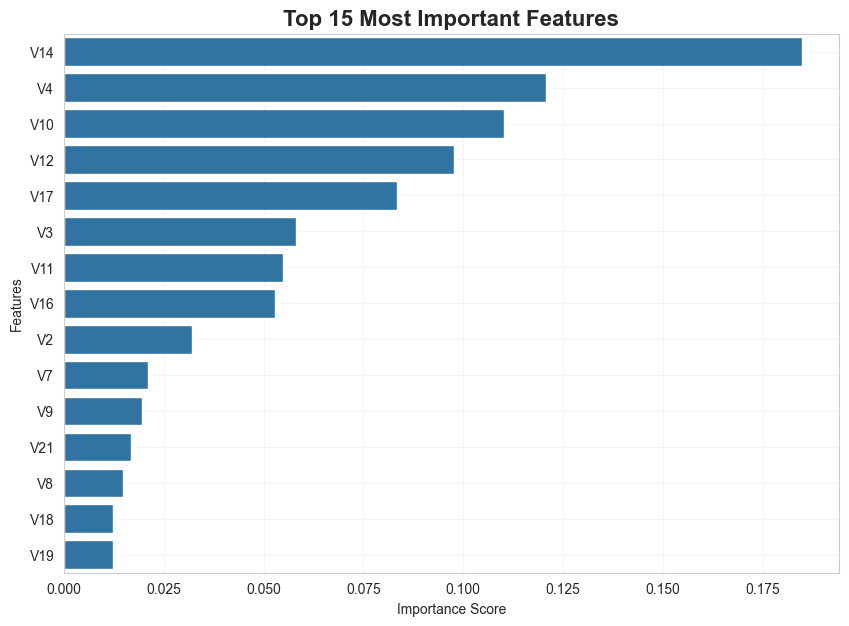

In [61]:
# ==========================================================
# Step 6.7: Top 15 Important Features
# ==========================================================

feature_importance = pd.DataFrame({

    "Feature": X.columns,
    "Importance": rf_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance.head(15))

plt.figure(figsize=(10,7))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Most Important Features",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.grid(alpha=0.2)

plt.show()

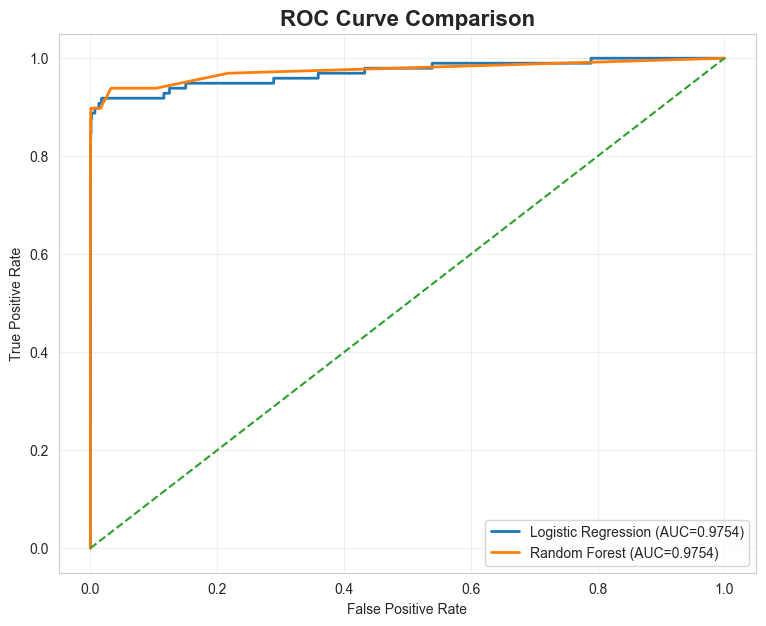

In [62]:
# ==========================================================
# Step 6.8: ROC Curve Comparison
# ==========================================================

from sklearn.metrics import roc_curve

# Logistic Regression
lr_fpr, lr_tpr, _ = roc_curve(y_test, y_prob_lr)

# Random Forest
rf_fpr, rf_tpr, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(9,7))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC={roc_auc:.4f})",
    linewidth=2
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC={rf_roc:.4f})",
    linewidth=2
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

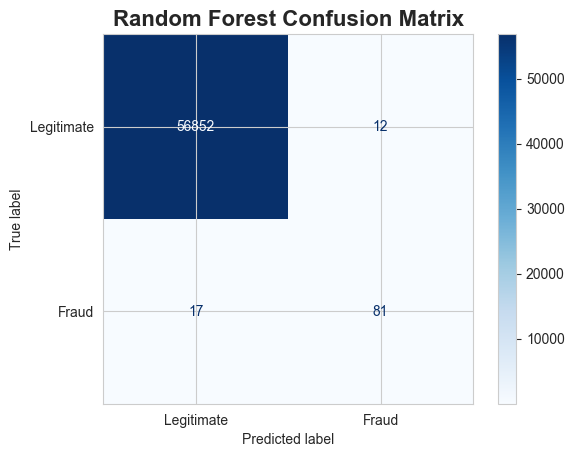

In [63]:
# ==========================================================
# Step 6.9: Random Forest Confusion Matrix
# ==========================================================

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Blues",
    display_labels=["Legitimate","Fraud"]
)

plt.title(
    "Random Forest Confusion Matrix",
    fontsize=16,
    fontweight="bold"
)

plt.show()

In [64]:
# ==========================================================
# Step 7.1: Save Final Random Forest Model
# ==========================================================

import joblib

joblib.dump(rf_model, "fraud_detection_model.pkl")

print("="*60)
print("MODEL SAVED SUCCESSFULLY")
print("="*60)

MODEL SAVED SUCCESSFULLY


In [65]:
# ==========================================================
# Step 7.2: Save StandardScaler
# ==========================================================

joblib.dump(scaler, "scaler.pkl")

print("="*60)
print("SCALER SAVED SUCCESSFULLY")
print("="*60)

SCALER SAVED SUCCESSFULLY


In [66]:
# ==========================================================
# Step 7.3: Load Saved Model
# ==========================================================

loaded_model = joblib.load("fraud_detection_model.pkl")

print("="*60)
print("MODEL LOADED SUCCESSFULLY")
print("="*60)

MODEL LOADED SUCCESSFULLY


In [67]:
# ==========================================================
# Step 7.4: Predict Sample Transactions
# ==========================================================

sample = X_test_scaled[:10]

prediction = loaded_model.predict(sample)

print("="*60)
print("SAMPLE PREDICTIONS")
print("="*60)

print(prediction)

SAMPLE PREDICTIONS
[0 0 0 0 0 0 0 0 0 0]


In [68]:
# ==========================================================
# Step 7.5: Save Feature Importance
# ==========================================================

feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("="*60)
print("FEATURE IMPORTANCE SAVED")
print("="*60)

FEATURE IMPORTANCE SAVED


In [69]:
# ==========================================================
# FINAL PROJECT SUMMARY
# ==========================================================

print("="*70)
print(" CREDIT CARD FRAUD DETECTION PROJECT SUMMARY")
print("="*70)

print(f"Dataset Size          : {df.shape}")
print(f"Total Features        : {X.shape[1]}")
print(f"Fraud Transactions    : {sum(df['Class']==1)}")
print(f"Normal Transactions   : {sum(df['Class']==0)}")

print("\nBest Model Selected : Random Forest")

print(f"\nAccuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")
print(f"ROC AUC   : {rf_roc:.4f}")

print("\nModel Saved Successfully")
print("Scaler Saved Successfully")

print("="*70)
print("PROJECT COMPLETED SUCCESSFULLY")
print("="*70)

 CREDIT CARD FRAUD DETECTION PROJECT SUMMARY
Dataset Size          : (284807, 31)
Total Features        : 30
Fraud Transactions    : 492
Normal Transactions   : 284315

Best Model Selected : Random Forest

Accuracy  : 0.9995
Precision : 0.8710
Recall    : 0.8265
F1 Score  : 0.8482
ROC AUC   : 0.9754

Model Saved Successfully
Scaler Saved Successfully
PROJECT COMPLETED SUCCESSFULLY
